# SupportSense — Scikit-learn Baseline

This notebook develops and evaluates classical machine-learning
models for customer-support intent classification using the
BANKING77 dataset.

Models:
1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM

The training data will be divided into training and validation
sets for model development. The official test set will remain
untouched until final model selection.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [3]:
DATA_DIR = Path("../data/raw")

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

print("Training data loaded:", train_df.shape)
print("Test data loaded:", test_df.shape)

Training data loaded: (10003, 2)
Test data loaded: (3080, 2)


In [4]:
train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [5]:
print(train_df.columns.tolist())

['text', 'category']


In [6]:
print(f"Training rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Number of training categories: {train_df['category'].nunique()}")

Training rows: 10,003
Test rows: 3,080
Number of training categories: 77


In [7]:
X = train_df["text"]
y = train_df["category"]

In [8]:
X.head()

0                       I am still waiting on my card?
1    What can I do if my card still hasn't arrived ...
2    I have been waiting over a week. Is the card s...
3    Can I track my card while it is in the process...
4    How do I know if I will get my card, or if it ...
Name: text, dtype: str

In [9]:
y.head()

0    card_arrival
1    card_arrival
2    card_arrival
3    card_arrival
4    card_arrival
Name: category, dtype: str

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10003,)
y shape: (10003,)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [12]:
print("Original training examples:", len(X))

print("\nAfter split:")
print("Training examples:", len(X_train))
print("Validation examples:", len(X_val))

Original training examples: 10003

After split:
Training examples: 8002
Validation examples: 2001


In [13]:
train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
)

validation_distribution = (
    y_val.value_counts(normalize=True)
    .sort_index()
)

distribution_comparison = pd.DataFrame({
    "train": train_distribution,
    "validation": validation_distribution
})

distribution_comparison.head(10)

,train,validation
category,,
Refund_not_showing_up,0.016246,0.015992
activate_my_card,0.015871,0.015992
age_limit,0.010997,0.010995
apple_pay_or_google_pay,0.012622,0.012494
atm_support,0.008748,0.008496
automatic_top_up,0.012747,0.012494
balance_not_updated_after_bank_transfer,0.017121,0.016992
balance_not_updated_after_cheque_or_cash_deposit,0.018120,0.017991
beneficiary_not_allowed,0.015621,0.015492


In [14]:
X_test = test_df["text"]
y_test = test_df["category"]

In [15]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (8002,)
Validation: (2001,)
Test: (3080,)


Logistic regression baseline
'First Model'

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


logistic_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [17]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](77,)","['Refund_not_showing_up','activate_my_card','age_limit',..., 'why_verify_identity','wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [18]:
val_predictions_logistic = logistic_model.predict(X_val)

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)


accuracy_logistic = accuracy_score(
    y_val,
    val_predictions_logistic
)

precision_logistic, recall_logistic, f1_logistic, _ = (
    precision_recall_fscore_support(
        y_val,
        val_predictions_logistic,
        average="macro"
    )
)

print(f"Accuracy_logistic:  {accuracy_logistic:.4f}")
print(f"Precision_logistic: {precision_logistic:.4f}")
print(f"Recall_logistic:    {recall_logistic:.4f}")
print(f"Logistic_Macro F1:  {f1_logistic:.4f}")

Accuracy_logistic:  0.8441
Precision_logistic: 0.8538
Recall_logistic:    0.8395
Logistic_Macro F1:  0.8416


In [20]:
results_logistic = pd.DataFrame({
    "text": X_val,
    "actual": y_val,
    "predicted": val_predictions_logistic,
})

errors_logistic = results_logistic[
    results_logistic["actual"] != results_logistic["predicted"]
]

errors_logistic.head(20)

,text,actual,predicted
2651,What are the fees imposed when I make a transa...,card_payment_fee_charged,cancel_transfer
4926,My withdrawals were going smooth until I got d...,declined_cash_withdrawal,declined_transfer
5433,What do I need to do for a refund?,request_refund,Refund_not_showing_up
1717,How can I reset my darned PIN number?,pin_blocked,change_pin
3602,Why is there an uknown charge showing on my ac...,card_payment_not_recognised,extra_charge_on_statement
9400,What's up with the extra fee I got?,cash_withdrawal_charge,card_payment_fee_charged
7536,Why has my payment not transferred?,failed_transfer,reverted_card_payment?
3899,I need help verifying my identity.,unable_to_verify_identity,why_verify_identity
2988,What currencies can be used for top up?,supported_cards_and_currencies,fiat_currency_support
2682,what is this extra charge with my purchase?,card_payment_fee_charged,extra_charge_on_statement


In [21]:
(
    errors_logistic
    .groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

actual                                   predicted                         
direct_debit_payment_not_recognised      card_payment_not_recognised           5
get_disposable_virtual_card              disposable_card_limits                5
top_up_by_bank_transfer_charge           top_up_by_card_charge                 4
top_up_failed                            pending_top_up                        4
transfer_fee_charged                     card_payment_fee_charged              4
why_verify_identity                      unable_to_verify_identity             4
direct_debit_payment_not_recognised      cash_withdrawal_not_recognised        3
declined_cash_withdrawal                 declined_transfer                     3
exchange_via_app                         exchange_charge                       3
change_pin                               pin_blocked                           3
topping_up_by_card                       top_up_by_cash_or_cheque              3
pending_transfer                 

Linear SVM
'Second Model'

In [22]:
from sklearn.svm import LinearSVC


svm_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

In [23]:
svm_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](77,)","['Refund_not_showing_up','activate_my_card','age_limit',..., 'why_verify_identity','wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [24]:
val_predictions_svm = svm_model.predict(X_val)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)


accuracy_svm = accuracy_score(
    y_val,
    val_predictions_svm
)

precision_svm, recall_svm, f1_svm, _ = (
    precision_recall_fscore_support(
        y_val,
        val_predictions_svm,
        average="macro"
    )
)

print(f"accuracy_svm:  {accuracy_svm:.4f}")
print(f"precision_svm: {precision_svm:.4f}")
print(f"recall_svm:    {recall_svm:.4f}")
print(f"Svm_Macro f1:  {f1_svm:.4f}")

accuracy_svm:  0.8806
precision_svm: 0.8849
recall_svm:    0.8833
Svm_Macro f1:  0.8819


In [26]:
results_svm = pd.DataFrame({
    "text": X_val,
    "actual": y_val,
    "predicted": val_predictions_svm,
})

errors_svm = results_svm[
    results_svm["actual"] != results_svm["predicted"]
]

errors_svm.head(20)

,text,actual,predicted
2651,What are the fees imposed when I make a transa...,card_payment_fee_charged,top_up_by_bank_transfer_charge
4926,My withdrawals were going smooth until I got d...,declined_cash_withdrawal,declined_card_payment
5433,What do I need to do for a refund?,request_refund,Refund_not_showing_up
1717,How can I reset my darned PIN number?,pin_blocked,change_pin
3602,Why is there an uknown charge showing on my ac...,card_payment_not_recognised,extra_charge_on_statement
9400,What's up with the extra fee I got?,cash_withdrawal_charge,card_payment_fee_charged
7536,Why has my payment not transferred?,failed_transfer,pending_card_payment
3899,I need help verifying my identity.,unable_to_verify_identity,why_verify_identity
3319,I put some money in my account the other day a...,balance_not_updated_after_cheque_or_cash_deposit,top_up_reverted
2988,What currencies can be used for top up?,supported_cards_and_currencies,fiat_currency_support


In [27]:
(
    errors_svm
    .groupby(["actual", "predicted"])
    .size()
    .sort_values(ascending=False)
    .head(20)
)

actual                                   predicted                                       
direct_debit_payment_not_recognised      card_payment_not_recognised                         6
pending_transfer                         transfer_not_received_by_recipient                  4
top_up_failed                            pending_top_up                                      4
pending_cash_withdrawal                  declined_cash_withdrawal                            3
card_arrival                             card_delivery_estimate                              3
fiat_currency_support                    supported_cards_and_currencies                      3
get_disposable_virtual_card              disposable_card_limits                              3
top_up_failed                            top_up_reverted                                     3
top_up_by_bank_transfer_charge           top_up_by_card_charge                               3
transfer_fee_charged                     card_payment_f

In [28]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_svm
    ],
    "Macro Precision": [
        precision_logistic,
        precision_svm
    ],
    "Macro Recall": [
        recall_logistic,
        recall_svm
    ],
    "Macro F1": [
        f1_logistic,
        f1_svm
    ]
})

In [29]:
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.844078,0.853797,0.839550,0.841646
1,Linear SVM,0.880560,0.884908,0.883286,0.881897


In [30]:
comparison_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.8441,0.8538,0.8395,0.8416
1,Linear SVM,0.8806,0.8849,0.8833,0.8819


In [31]:
comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
)

comparison_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
1,Linear SVM,0.8806,0.8849,0.8833,0.8819
0,Logistic Regression,0.8441,0.8538,0.8395,0.8416


In [32]:
f1_difference = f1_svm - f1_logistic

print(
    f"Macro F1 difference: {f1_difference:.4f}"
)

Macro F1 difference: 0.0403


In [33]:
relative_improvement = (
    (f1_svm - f1_logistic)
    / f1_logistic
) * 100

print(
    f"Relative Macro F1 improvement: "
    f"{relative_improvement:.2f}%"
)

Relative Macro F1 improvement: 4.78%


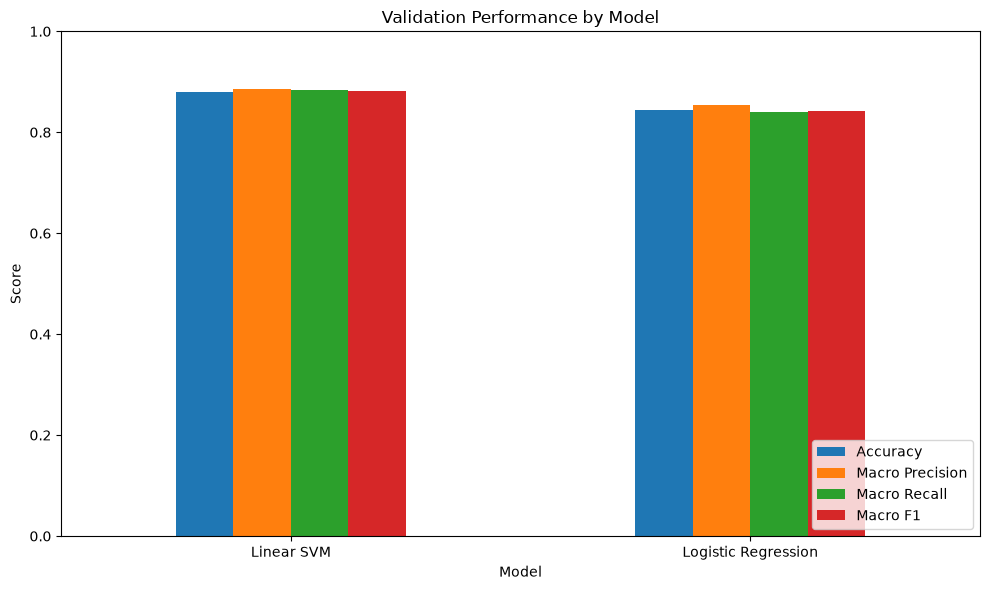

In [34]:
comparison_df.plot(
    x="Model",
    y=[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Validation Performance by Model")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()

plt.show()

## Model Comparison

The Logistic Regression and Linear SVM models were evaluated
using the same validation dataset to ensure a fair comparison.

The primary model-selection metric is Macro F1 because the
classification problem contains 77 intent categories. Macro F1
calculates F1 independently for each category before averaging
the results, preventing performance on larger classes from
dominating the overall evaluation.

### Findings

- Best validation model: Linear SVM
- Validation accuracy: 0.8806
- Validation Macro F1: 0.8819
- Difference in Macro F1: 0.0413

### Interpretation

Linear SVM achieved the strongest validation performance across all
four evaluation metrics. It achieved an accuracy of 0.8806 and a
Macro F1 score of 0.8819, compared with 0.8441 accuracy and 0.8416
Macro F1 for Logistic Regression.

This represents an absolute improvement of 0.0403 (4.03 percentage
points) in Macro F1 over the Logistic Regression baseline.

The improvement in Macro F1 is particularly relevant because the
problem contains 77 intent categories. Macro F1 gives equal importance
to each class when calculating the overall score, rather than allowing
performance on more frequent classes to dominate the result.

Based on validation performance, Linear SVM is the stronger candidate
for further experimentation. However, the official test set remains
untouched at this stage and will only be used after model selection and
hyperparameter experimentation are complete.

## Hyperparameter Experimentation

Linear SVM achieved the strongest baseline validation performance,
with a Macro F1 score of 0.8819.

The next stage evaluates different TF-IDF and Linear SVM
hyperparameters using only the training and validation datasets.

The official test dataset remains untouched during hyperparameter
selection.

In [35]:
from itertools import product

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [36]:
ngram_options = [
    (1, 1),
    (1, 2)
]

min_df_options = [
    1,
    2,
    3
]

c_options = [
    0.1,
    0.5,
    1.0,
    2.0,
    5.0
]

In [37]:
print(
    "Number of experiments:",
    len(ngram_options)
    * len(min_df_options)
    * len(c_options)
)

Number of experiments: 30


In [38]:
experiment_results = []

In [39]:
for ngram_range, min_df, c_value in product(
    ngram_options,
    min_df_options,
    c_options
):
    print(
        f"Testing: "
        f"ngram={ngram_range}, "
        f"min_df={min_df}, "
        f"C={c_value}"
    )

    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=ngram_range,
                min_df=min_df
            )
        ),
        (
            "classifier",
            LinearSVC(
                C=c_value
            )
        )
    ])

    # Train ONLY on our training subset.
    model.fit(
        X_train,
        y_train
    )

    # Evaluate ONLY on validation.
    predictions = model.predict(
        X_val
    )

    accuracy = accuracy_score(
        y_val,
        predictions
    )

    precision = precision_score(
        y_val,
        predictions,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_val,
        predictions,
        average="macro",
        zero_division=0
    )

    experiment_results.append({
        "ngram_range": str(ngram_range),
        "min_df": min_df,
        "C": c_value,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": macro_f1
    })

Testing: ngram=(1, 1), min_df=1, C=0.1
Testing: ngram=(1, 1), min_df=1, C=0.5
Testing: ngram=(1, 1), min_df=1, C=1.0
Testing: ngram=(1, 1), min_df=1, C=2.0
Testing: ngram=(1, 1), min_df=1, C=5.0
Testing: ngram=(1, 1), min_df=2, C=0.1
Testing: ngram=(1, 1), min_df=2, C=0.5
Testing: ngram=(1, 1), min_df=2, C=1.0
Testing: ngram=(1, 1), min_df=2, C=2.0
Testing: ngram=(1, 1), min_df=2, C=5.0
Testing: ngram=(1, 1), min_df=3, C=0.1
Testing: ngram=(1, 1), min_df=3, C=0.5
Testing: ngram=(1, 1), min_df=3, C=1.0
Testing: ngram=(1, 1), min_df=3, C=2.0
Testing: ngram=(1, 1), min_df=3, C=5.0
Testing: ngram=(1, 2), min_df=1, C=0.1
Testing: ngram=(1, 2), min_df=1, C=0.5
Testing: ngram=(1, 2), min_df=1, C=1.0
Testing: ngram=(1, 2), min_df=1, C=2.0
Testing: ngram=(1, 2), min_df=1, C=5.0
Testing: ngram=(1, 2), min_df=2, C=0.1
Testing: ngram=(1, 2), min_df=2, C=0.5
Testing: ngram=(1, 2), min_df=2, C=1.0
Testing: ngram=(1, 2), min_df=2, C=2.0
Testing: ngram=(1, 2), min_df=2, C=5.0
Testing: ngram=(1, 2), mi

In [40]:
experiments_df = pd.DataFrame(
    experiment_results
)

experiments_df.head()

,ngram_range,min_df,C,Accuracy,Macro Precision,Macro Recall,Macro F1
0,"(1, 1)",1,0.1,0.861069,0.868545,0.855557,0.853953
1,"(1, 1)",1,0.5,0.884558,0.888881,0.883804,0.883605
2,"(1, 1)",1,1.0,0.883558,0.887562,0.884061,0.883441
3,"(1, 1)",1,2.0,0.881559,0.883686,0.881629,0.880310
4,"(1, 1)",1,5.0,0.875062,0.876108,0.875106,0.872962


### SORTING BY MACRO F1

In [41]:
experiments_df = experiments_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

experiments_df.head(10).round(4)

,ngram_range,min_df,C,Accuracy,Macro Precision,Macro Recall,Macro F1
0,"(1, 2)",1,2.0,0.8846,0.8879,0.8868,0.8853
1,"(1, 2)",1,1.0,0.8831,0.8876,0.8851,0.8841
2,"(1, 2)",2,0.5,0.8831,0.8873,0.8849,0.8838
3,"(1, 1)",1,0.5,0.8846,0.8889,0.8838,0.8836
4,"(1, 1)",1,1.0,0.8836,0.8876,0.8841,0.8834
5,"(1, 1)",2,0.5,0.8831,0.8868,0.8828,0.8824
6,"(1, 2)",2,1.0,0.8806,0.8849,0.8833,0.8819
7,"(1, 2)",3,0.5,0.8791,0.8838,0.8819,0.8807
8,"(1, 2)",1,5.0,0.8796,0.8831,0.8819,0.8805
9,"(1, 1)",2,1.0,0.8816,0.8838,0.8813,0.8804


In [42]:
# EXTRACTING THE HIGHEST VALIDATION MACRO F1
best_experiment = experiments_df.iloc[0]

best_experiment

ngram_range          (1, 2)
min_df                    1
C                       2.0
Accuracy           0.884558
Macro Precision    0.887922
Macro Recall       0.886797
Macro F1           0.885329
Name: 0, dtype: object

In [43]:
print("BEST CONFIGURATION")
print("------------------")
print(
    "ngram_range:",
    best_experiment["ngram_range"]
)
print(
    "min_df:",
    best_experiment["min_df"]
)
print(
    "C:",
    best_experiment["C"]
)
print(
    "Validation Accuracy:",
    round(
        best_experiment["Accuracy"],
        4
    )
)
print(
    "Validation Macro F1:",
    round(
        best_experiment["Macro F1"],
        4
    )
)

BEST CONFIGURATION
------------------
ngram_range: (1, 2)
min_df: 1
C: 2.0
Validation Accuracy: 0.8846
Validation Macro F1: 0.8853


### COMPARING AGAINST THE OLD SVM
Original SVM had:
Accuracy = 0.8806
Macro F1= 0.8819

In [44]:
baseline_f1 = 0.8819

best_f1 = best_experiment[
    "Macro F1"
]

improvement = (
    best_f1 - baseline_f1
)

print(
    f"Baseline Macro F1: "
    f"{baseline_f1:.4f}"
)

print(
    f"Best Macro F1: "
    f"{best_f1:.4f}"
)

print(
    f"Absolute improvement: "
    f"{improvement:.4f}"
)

Baseline Macro F1: 0.8819
Best Macro F1: 0.8853
Absolute improvement: 0.0034


### SPECIFICALLY EXAMINE C
Making the effects visible

In [45]:
(
    experiments_df[
        experiments_df["ngram_range"]
        == "(1, 2)"
    ]
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .head(15)
    .round(4)
)

,ngram_range,min_df,C,Accuracy,Macro Precision,Macro Recall,Macro F1
0,"(1, 2)",1,2.0,0.8846,0.8879,0.8868,0.8853
1,"(1, 2)",1,1.0,0.8831,0.8876,0.8851,0.8841
2,"(1, 2)",2,0.5,0.8831,0.8873,0.8849,0.8838
6,"(1, 2)",2,1.0,0.8806,0.8849,0.8833,0.8819
7,"(1, 2)",3,0.5,0.8791,0.8838,0.8819,0.8807
8,"(1, 2)",1,5.0,0.8796,0.8831,0.8819,0.8805
12,"(1, 2)",1,0.5,0.8786,0.8844,0.8798,0.8796
14,"(1, 2)",2,2.0,0.8771,0.8816,0.8801,0.8787
15,"(1, 2)",3,2.0,0.8766,0.8814,0.8799,0.8782
16,"(1, 2)",3,1.0,0.8761,0.8818,0.8796,0.8782


In [46]:
# Calculating the average performance for each C
c_comparison = (
    experiments_df
    .groupby("C")["Macro F1"]
    .mean()
    .reset_index()
    .sort_values(
        "Macro F1",
        ascending=False
    )
)

c_comparison.round(4)

,C,Macro F1
1,0.5,0.8816
2,1.0,0.8805
3,2.0,0.8791
4,5.0,0.8725
0,0.1,0.8506


### Hyperparameter Experiment Results

A total of 30 Linear SVM configurations were evaluated using
the validation dataset.

The experiments varied:

- TF-IDF n-gram range
- minimum document frequency (`min_df`)
- Linear SVM regularisation parameter (`C`)

The best-performing configuration was:

- `ngram_range`: (1, 2)
- `min_df`: 1
- `C`: 2.0
- Validation Accuracy: 0.8846
- Validation Macro F1: 0.8853


The original Linear SVM baseline achieved a Macro F1 of 0.8819.
The selected configuration therefore produced an absolute difference of 0.0034.

The final configuration was selected using validation performance
only. The official test set was not used during hyperparameter
selection.

### RETRAINING THE MODEL WITH THE ORIGINAL TRAINING DATA USING THE THE BEST CONFIGURATION (LINEAR SVM)

In [47]:
print("Original training shape:", train_df.shape)
print("Official test shape:", test_df.shape)

Original training shape: (10003, 2)
Official test shape: (3080, 2)


In [48]:
X_full_train = train_df["text"]
y_full_train = train_df["category"]

X_test = test_df["text"]
y_test = test_df["category"]

In [49]:
print("Full training examples:", len(X_full_train))
print("Test examples:", len(X_test))

print("Full training labels:", len(y_full_train))
print("Test labels:", len(y_test))

Full training examples: 10003
Test examples: 3080
Full training labels: 10003
Test labels: 3080


X_full_train
= 10,003 customer messages

y_full_train
= 10,003 correct intents


X_test
= 3,080 unseen customer messages

y_test
= 3,080 correct intents

### Create a fresh model.

### Because we want a clean model that gets trained from scratch using all 10,003 training examples.

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

Using the best configuration

In [51]:
experiments_df.head(10).round(4)

,ngram_range,min_df,C,Accuracy,Macro Precision,Macro Recall,Macro F1
0,"(1, 2)",1,2.0,0.8846,0.8879,0.8868,0.8853
1,"(1, 2)",1,1.0,0.8831,0.8876,0.8851,0.8841
2,"(1, 2)",2,0.5,0.8831,0.8873,0.8849,0.8838
3,"(1, 1)",1,0.5,0.8846,0.8889,0.8838,0.8836
4,"(1, 1)",1,1.0,0.8836,0.8876,0.8841,0.8834
5,"(1, 1)",2,0.5,0.8831,0.8868,0.8828,0.8824
6,"(1, 2)",2,1.0,0.8806,0.8849,0.8833,0.8819
7,"(1, 2)",3,0.5,0.8791,0.8838,0.8819,0.8807
8,"(1, 2)",1,5.0,0.8796,0.8831,0.8819,0.8805
9,"(1, 1)",2,1.0,0.8816,0.8838,0.8813,0.8804


In [52]:
# Get the best experiment results
best_experiment = experiments_df.iloc[0]

best_experiment

ngram_range          (1, 2)
min_df                    1
C                       2.0
Accuracy           0.884558
Macro Precision    0.887922
Macro Recall       0.886797
Macro F1           0.885329
Name: 0, dtype: object

In [53]:
print("BEST SVM CONFIGURATION")
print("---------------------------")
print(f"ngram_range: {best_experiment['ngram_range']}")
print(f"min_df: {best_experiment['min_df']}")
print(f"C: {best_experiment['C']}")
print(f"Validation Accuracy: {best_experiment['Accuracy']:.4f}")
print(f"Validation Macro F1: {best_experiment['Macro F1']:.4f}")

BEST SVM CONFIGURATION
---------------------------
ngram_range: (1, 2)
min_df: 1
C: 2.0
Validation Accuracy: 0.8846
Validation Macro F1: 0.8853


In [54]:
BEST_NGRAM_RANGE = (1, 2)
BEST_MIN_DF = 1
BEST_C = 2.0

In [55]:
print("Final hyperparameters:")
print("ngram_range =", BEST_NGRAM_RANGE)
print("min_df =", BEST_MIN_DF)
print("C =", BEST_C)

Final hyperparameters:
ngram_range = (1, 2)
min_df = 1
C = 2.0


In [56]:
best_validation_accuracy = best_experiment["Accuracy"]
best_validation_f1 = best_experiment["Macro F1"]

print(
    f"Best validation accuracy: "
    f"{best_validation_accuracy:.4f}"
)

print(
    f"Best validation Macro F1: "
    f"{best_validation_f1:.4f}"
)

Best validation accuracy: 0.8846
Best validation Macro F1: 0.8853


In [57]:
print("Original training dataset:")
print(train_df.shape)

print("\nOfficial test dataset:")
print(test_df.shape)

Original training dataset:
(10003, 2)

Official test dataset:
(3080, 2)


In [58]:
print(train_df.columns.tolist())
print(test_df.columns.tolist())

['text', 'category']
['text', 'category']


In [59]:
final_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            ngram_range=BEST_NGRAM_RANGE,
            min_df=BEST_MIN_DF
        )
    ),
    (
        "classifier",
        LinearSVC(
            C=BEST_C
        )
    )
])

In [60]:
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None


In [61]:
### Train on all 10,003 original training examples

print("Training final model...")

final_model.fit(
    X_full_train,
    y_full_train
)

print("Training complete.")

Training final model...
Training complete.


In [62]:
# Make the final test predictions. Training on the official test data

test_predictions = final_model.predict(
    X_test
)

In [63]:
print(
    "Number of test predictions:",
    len(test_predictions)
)

Number of test predictions: 3080


In [64]:
test_predictions[:10]

array(['get_physical_card', 'card_arrival',
       'transfer_not_received_by_recipient', 'card_arrival',
       'card_arrival', 'card_delivery_estimate', 'card_arrival',
       'card_arrival', 'card_arrival', 'card_arrival'], dtype=object)

In [65]:
# Test results table
test_results = pd.DataFrame({
    "text": X_test.to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": test_predictions
})

test_results.head(10)

,text,actual,predicted
0,How do I locate my card?,card_arrival,get_physical_card
1,"I still have not received my new card, I order...",card_arrival,card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival
4,My card has not arrived yet.,card_arrival,card_arrival
5,When will I get my card?,card_arrival,card_delivery_estimate
6,Do you know if there is a tracking number for ...,card_arrival,card_arrival
7,i have not received my card,card_arrival,card_arrival
8,still waiting on that card,card_arrival,card_arrival
9,Is it normal to have to wait over a week for m...,card_arrival,card_arrival


In [66]:
test_results["correct"] = (
    test_results["actual"]
    == test_results["predicted"]
)

test_results.head(10)

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
1,"I still have not received my new card, I order...",card_arrival,card_arrival,True
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient,False
3,Is there a way to know when my card will arrive?,card_arrival,card_arrival,True
4,My card has not arrived yet.,card_arrival,card_arrival,True
5,When will I get my card?,card_arrival,card_delivery_estimate,False
6,Do you know if there is a tracking number for ...,card_arrival,card_arrival,True
7,i have not received my card,card_arrival,card_arrival,True
8,still waiting on that card,card_arrival,card_arrival,True
9,Is it normal to have to wait over a week for m...,card_arrival,card_arrival,True


In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [68]:
final_accuracy = accuracy_score(
    y_test,
    test_predictions
)

final_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

In [69]:
print("FINAL TEST RESULTS")
print("------------------")
print(f"Accuracy:        {final_accuracy:.4f}")
print(f"Macro Precision: {final_precision:.4f}")
print(f"Macro Recall:    {final_recall:.4f}")
print(f"Macro F1:        {final_f1:.4f}")

FINAL TEST RESULTS
------------------
Accuracy:        0.8932
Macro Precision: 0.8967
Macro Recall:    0.8932
Macro F1:        0.8934


In [70]:
final_results_df = pd.DataFrame([
    {
        "Model": "TF-IDF + Linear SVM",
        "Accuracy": final_accuracy,
        "Macro Precision": final_precision,
        "Macro Recall": final_recall,
        "Macro F1": final_f1
    }
])

final_results_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF + Linear SVM,0.8932,0.8967,0.8932,0.8934


In [71]:
validation_vs_test = pd.DataFrame([
    {
        "Dataset": "Validation",
        "Accuracy": best_validation_accuracy,
        "Macro F1": best_validation_f1
    },
    {
        "Dataset": "Official Test",
        "Accuracy": final_accuracy,
        "Macro F1": final_f1
    }
])

validation_vs_test.round(4)

,Dataset,Accuracy,Macro F1
0,Validation,0.8846,0.8853
1,Official Test,0.8932,0.8934


In [72]:
# Calculating Validation-vs-test difference
accuracy_gap = (
    best_validation_accuracy
    - final_accuracy
)

f1_gap = (
    best_validation_f1
    - final_f1
)

print(
    f"Validation-to-test accuracy difference: "
    f"{accuracy_gap:.4f}"
)

print(
    f"Validation-to-test Macro F1 difference: "
    f"{f1_gap:.4f}"
)

Validation-to-test accuracy difference: -0.0086
Validation-to-test Macro F1 difference: -0.0080


In [73]:
# Generate the full classification report
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.95      0.95      0.95        40
                                activate_my_card       0.97      0.97      0.97        40
                                       age_limit       0.95      1.00      0.98        40
                         apple_pay_or_google_pay       1.00      0.97      0.99        40
                                     atm_support       0.93      0.93      0.93        40
                                automatic_top_up       0.97      0.97      0.97        40
         balance_not_updated_after_bank_transfer       0.67      0.75      0.71        40
balance_not_updated_after_cheque_or_cash_deposit       0.88      0.93      0.90        40
                         beneficiary_not_allowed       0.95      0.95      0.95        40
                                 cancel_transfer       0.95      0.95      0.95        40
         

In [74]:
# Convert the report to a DataFrame. A dataframe is much easier to analyse
report = classification_report(
    y_test,
    test_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report
).transpose()

report_df.head()

,precision,recall,f1-score,support
Refund_not_showing_up,0.950000,0.950,0.950000,40.0
activate_my_card,0.975000,0.975,0.975000,40.0
age_limit,0.952381,1.000,0.975610,40.0
apple_pay_or_google_pay,1.000000,0.975,0.987342,40.0
atm_support,0.925000,0.925,0.925000,40.0


In [75]:
class_report_df = report_df.loc[
    ~report_df.index.isin([
        "accuracy",
        "macro avg",
        "weighted avg"
    ])
].copy()

In [76]:
class_report_df.shape

(77, 4)

In [77]:
# Find 10 weakest classes
worst_classes = (
    class_report_df
    .sort_values(
        by="f1-score",
        ascending=True
    )
    .head(10)
)

worst_classes.round(4)

,precision,recall,f1-score,support
balance_not_updated_after_bank_transfer,0.6667,0.750,0.7059,40.0
top_up_failed,0.7317,0.750,0.7407,40.0
pending_transfer,0.8235,0.700,0.7568,40.0
verify_my_identity,0.7692,0.750,0.7595,40.0
card_not_working,0.6939,0.850,0.7640,40.0
transfer_not_received_by_recipient,0.7619,0.800,0.7805,40.0
wrong_exchange_rate_for_cash_withdrawal,0.8333,0.750,0.7895,40.0
failed_transfer,0.7391,0.850,0.7907,40.0
topping_up_by_card,0.8611,0.775,0.8158,40.0
extra_charge_on_statement,0.8095,0.850,0.8293,40.0


In [78]:
# Find 10 strongest classes
best_classes = (
    class_report_df
    .sort_values(
        by="f1-score",
        ascending=False
    )
    .head(10)
)

best_classes.round(4)

,precision,recall,f1-score,support
terminate_account,1.0000,1.000,1.0000,40.0
passcode_forgotten,1.0000,1.000,1.0000,40.0
edit_personal_details,0.9756,1.000,0.9877,40.0
verify_top_up,0.9756,1.000,0.9877,40.0
apple_pay_or_google_pay,1.0000,0.975,0.9873,40.0
receiving_money,1.0000,0.975,0.9873,40.0
age_limit,0.9524,1.000,0.9756,40.0
lost_or_stolen_phone,0.9750,0.975,0.9750,40.0
activate_my_card,0.9750,0.975,0.9750,40.0
automatic_top_up,0.9750,0.975,0.9750,40.0


In [79]:
# Extract every incorrect prediction
test_errors = test_results[
    test_results["correct"] == False
].copy()

In [80]:
print(
    f"Correct predictions: "
    f"{test_results['correct'].sum():,}"
)

print(
    f"Incorrect predictions: "
    f"{len(test_errors):,}"
)

print(
    f"Total predictions: "
    f"{len(test_results):,}"
)

Correct predictions: 2,751
Incorrect predictions: 329
Total predictions: 3,080


In [81]:
test_errors.head(20)

,text,actual,predicted,correct
0,How do I locate my card?,card_arrival,get_physical_card,False
2,I ordered a card but it has not arrived. Help ...,card_arrival,transfer_not_received_by_recipient,False
5,When will I get my card?,card_arrival,card_delivery_estimate,False
11,How long does a card delivery take?,card_arrival,card_delivery_estimate,False
36,I'm starting to think my card is lost because ...,card_arrival,lost_or_stolen_card,False
79,Can I link another card to my account?,card_linking,getting_spare_card,False
93,Is it a good time to exchange?,exchange_rate,exchange_charge,False
106,The exchange rate would be?,exchange_rate,wrong_exchange_rate_for_cash_withdrawal,False
123,The exchange rate was wrong when I bought some...,card_payment_wrong_exchange_rate,wrong_exchange_rate_for_cash_withdrawal,False
138,Why am I being charged more ?,card_payment_wrong_exchange_rate,card_payment_fee_charged,False


In [82]:
# Find the most common mistakes
confusion_pairs = (
    test_errors
    .groupby([
        "actual",
        "predicted"
    ])
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        by="count",
        ascending=False
    )
)

confusion_pairs.head(20)

,actual,predicted,count
214,verify_my_identity,why_verify_identity,5
209,unable_to_verify_identity,verify_my_identity,5
10,balance_not_updated_after_bank_transfer,transfer_not_received_by_recipient,4
145,pending_top_up,top_up_failed,4
149,pending_transfer,failed_transfer,4
20,card_acceptance,card_not_working,4
176,top_up_failed,top_up_reverted,4
226,wrong_exchange_rate_for_cash_withdrawal,card_payment_wrong_exchange_rate,4
148,pending_transfer,balance_not_updated_after_bank_transfer,4
180,top_up_reverted,top_up_failed,4


In [83]:
# Inspect the worst confusion pair automatically
top_confusion = confusion_pairs.iloc[0]

top_actual = top_confusion["actual"]
top_predicted = top_confusion["predicted"]

print("Most common confusion:")
print("Actual:", top_actual)
print("Predicted:", top_predicted)
print("Count:", top_confusion["count"])

Most common confusion:
Actual: verify_my_identity
Predicted: why_verify_identity
Count: 5


In [84]:
test_errors[
    (test_errors["actual"] == top_actual)
    &
    (test_errors["predicted"] == top_predicted)
][
    [
        "text",
        "actual",
        "predicted"
    ]
].head(10)

,text,actual,predicted
3001,What do you need to verify my identity?,verify_my_identity,why_verify_identity
3005,What do you need for my identity check?,verify_my_identity,why_verify_identity
3012,I need to verify my identity,verify_my_identity,why_verify_identity
3020,How does my identity get verified?,verify_my_identity,why_verify_identity
3035,Is there any way to verify who I am?,verify_my_identity,why_verify_identity


In [85]:
# Create the confusion matrix data
labels = sorted(
    y_test.unique()
)

cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=labels
)

print(
    "Confusion matrix shape:",
    cm.shape
)

Confusion matrix shape: (77, 77)


In [86]:
# Save useful evaluation results
from pathlib import Path

REPORTS_DIR = Path(
    "../reports"
)

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [87]:
final_results_df.to_csv(
    REPORTS_DIR / "final_test_metrics.csv",
    index=False
)

class_report_df.to_csv(
    REPORTS_DIR / "class_test_metrics.csv"
)

confusion_pairs.to_csv(
    REPORTS_DIR / "confusion_pairs.csv",
    index=False
)

test_results.to_csv(
    REPORTS_DIR / "test_predictions.csv",
    index=False
)

print("Evaluation reports saved.")

Evaluation reports saved.


In [88]:
# Save the final trained model
import joblib

MODEL_DIR = Path(
    "../models"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    MODEL_DIR
    / "supportsense_sklearn.joblib"
)

In [89]:
joblib.dump(
    final_model,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: ../models/supportsense_sklearn.joblib


In [90]:
# Reload the model
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Model loaded successfully."
)

Model loaded successfully.


In [91]:
# Test on completely new messages
example_queries = [
    "I forgot my PIN",
    "My new card still hasn't arrived",
    "Why did my bank transfer fail?",
    "I was charged twice for the same thing",
    "The cash machine did not give me my money"
]

example_predictions = loaded_model.predict(
    example_queries
)

for query, prediction in zip(
    example_queries,
    example_predictions
):
    print(f"Query: {query}")
    print(f"Prediction: {prediction}")
    print("-" * 60)

Query: I forgot my PIN
Prediction: pin_blocked
------------------------------------------------------------
Query: My new card still hasn't arrived
Prediction: card_arrival
------------------------------------------------------------
Query: Why did my bank transfer fail?
Prediction: failed_transfer
------------------------------------------------------------
Query: I was charged twice for the same thing
Prediction: transaction_charged_twice
------------------------------------------------------------
Query: The cash machine did not give me my money
Prediction: wrong_amount_of_cash_received
------------------------------------------------------------


## Final Linear SVM Evaluation

### Training Strategy

Following model selection and hyperparameter experimentation, the
selected TF-IDF and Linear SVM configuration was retrained from
scratch using the complete original BANKING77 training dataset of
10,003 queries.

The official test set of 3,080 queries was kept separate during
model development and hyperparameter selection and was used only
for final evaluation.

### Selected Hyperparameters

- TF-IDF n-gram range: `1,2`
- TF-IDF minimum document frequency: `1`
- Linear SVM C: `2.0`

### Final Test Performance

- Accuracy: **0.8932**
- Macro Precision: **0.8967**
- Macro Recall: **0.8932**
- Macro F1: **0.8934**

### Validation vs Test Performance

The selected configuration achieved a validation Macro F1 of
**0.8853** and a final test Macro F1 of **0.8934**.

The validation-to-test Macro F1 difference was **-0.0080**.

There was no substantial difference in the validation and test performance Macro F1's. The two results were reasonably similar

### Error Analysis

The lowest-performing intents included:

Failed_transfer	0.7391	0.850	0.7907	40.0
topping_up_by_card	0.8611	0.775	0.8158	40.0
extra_charge_on_statement	

- failed_transfer
- topping_up_by_card
- extra_charge_on_statement

Common confusion pairs included:

- `[ACTUAL]` → `[PREDICTED]`
- `verify_my_identity` → `why_verify_identity`
- `unable_to_verify_identity` → `verify_my_identity`
- `balance_not_updated_after_bank_transfer` → `transfer_not_received_by_recipient`


### Conclusion

The final results suggests that the model has high ability to classify previously unseen banking support queries.